In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path

pd.set_option("display.max_columns", None)   # see every column when inspecting
sns.set_theme(style="whitegrid")
RAW = Path("../data/raw")               

### 1. Load & Merge

In [2]:
# low_memory=False: the StateHoliday column mixes types, which otherwise triggers a dtype warning.
train = pd.read_csv(RAW / "train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv(RAW / "store.csv")
print("train:", train.shape, "| store:", store.shape)
train.head()

train: (1017209, 9) | store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
print(train["StateHoliday"].value_counts(dropna=False))  
train["StateHoliday"] = train["StateHoliday"].astype(str)

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [5]:
# Left join: train is the source of truth (one row per store-day) - guarantees we never drop a sales record even if a store's metadata were missing.
df = train.merge(store, on="Store", how="left")
print("merged:", df.shape)
df.head()

merged: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 2. First Look

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [7]:
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870


In [8]:
print("date range:", df["Date"].min().date(), "->", df["Date"].max().date())
print("number of stores:", df["Store"].nunique())

date range: 2013-01-01 -> 2015-07-31
number of stores: 1115


### 3. Data Quality

In [9]:
# Missing Values
missing = df.isna().sum()
missing[missing > 0]

CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [10]:
df.groupby("Open")["Sales"].agg(["mean", "count"])

,mean,count
Open,,
0,0.000000,172817
1,6955.514291,844392


In [11]:
print("closed rows :", (df["Open"] == 0).sum())
print("zero-sales rows:", (df["Sales"] == 0).sum())   # almost all zero-sales rows are simply closed days

closed rows : 172817
zero-sales rows: 172871


In [ ]:
# Closed days are Sales = 0 - that's "no opportunity, not no demand". Training on them would teach the model the store - calendar (e.g. "Sundays = 0") instead of buying behaviour. Decision: model open days only.

open_df = df[df["Open"] == 1].copy()
print("modelling rows (open days):", f"{len(open_df):,}")

modelling rows (open days): 844,392


In [13]:
# how many holiday rows actually survive on trading days?
open_df["StateHoliday"].value_counts()

StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

In [14]:
# Duplicates 
print("duplicate store-date rows:", df.duplicated(subset=["Store", "Date"]).sum())

duplicate store-date rows: 0


### 4. SQL layer

Load the merged data into SQLite and answer two business questions in SQL - this is what makes "SQL" a real,
demonstrable skill on this project rather than just `read_csv`.

In [15]:
conn = sqlite3.connect("../data/rossmann.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

1017209

In [16]:
# Q: which store format is most valuable per trading day?
pd.read_sql('''
    SELECT StoreType,
           ROUND(AVG(Sales)) AS avg_daily_sales,
           COUNT(DISTINCT Store) AS n_stores
    FROM sales
    WHERE Open = 1
    GROUP BY StoreType
    ORDER BY avg_daily_sales DESC;
''', conn)

,StoreType,avg_daily_sales,n_stores
0,b,10231.0,17
1,c,6933.0,148
2,a,6925.0,602
3,d,6822.0,348


In [17]:
# Q: how much does a promotion lift average daily sales?
pd.read_sql('''
    SELECT Promo,
           ROUND(AVG(Sales)) AS avg_daily_sales,
           COUNT(*) AS n_days
    FROM sales
    WHERE Open = 1
    GROUP BY Promo;
''', conn)

,Promo,avg_daily_sales,n_days
0,0,5929.0,467496
1,1,8228.0,376896


### 5. Target analysis: what does demand look like?

**Business question:** *is sales skewed, and do we need to transform it before modelling?*

skew: 1.59 | kurtosis: 4.85


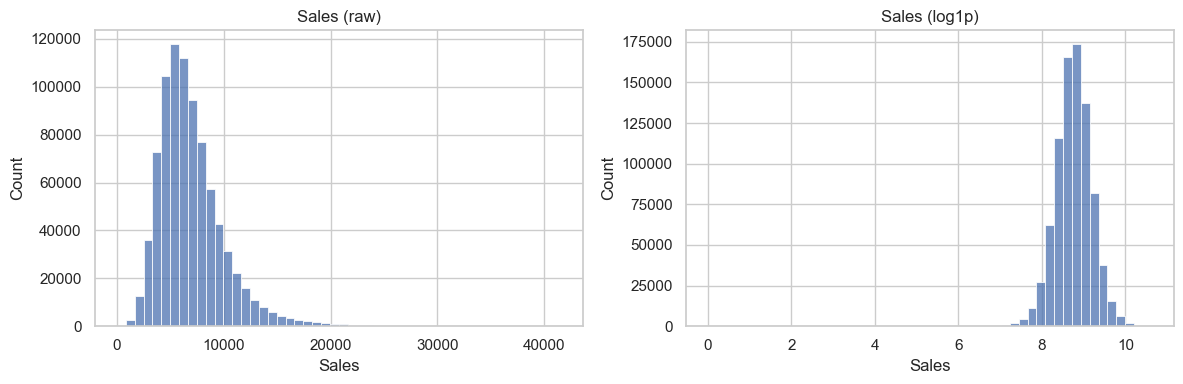

In [18]:
print("skew:", round(open_df["Sales"].skew(), 2), "| kurtosis:", round(open_df["Sales"].kurt(), 2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(open_df["Sales"], bins=50, ax=ax[0]); ax[0].set_title("Sales (raw)")
sns.histplot(np.log1p(open_df["Sales"]), bins=50, ax=ax[1]); ax[1].set_title("Sales (log1p)")
plt.tight_layout(); plt.show()

### 6. Trends & drivers

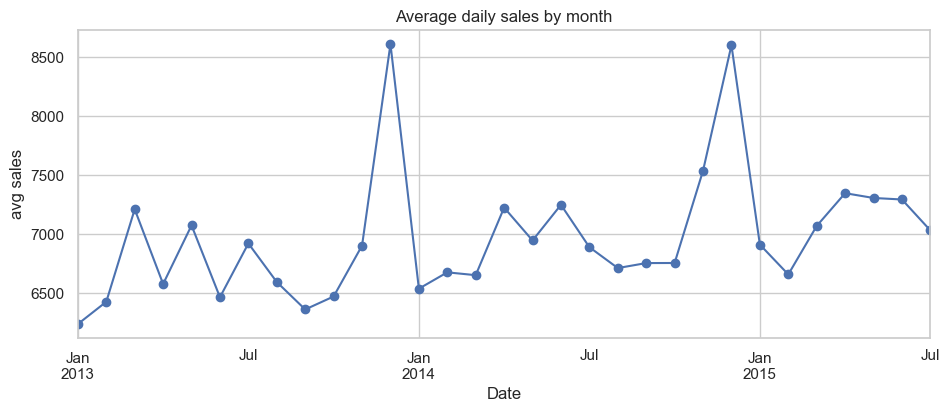

In [19]:
# When across the year is demand highest? (→ when to pre-stock inventory)
monthly = open_df.groupby(open_df["Date"].dt.to_period("M"))["Sales"].mean()
monthly.index = monthly.index.to_timestamp()
monthly.plot(figsize=(11, 4), marker="o", title="Average daily sales by month")
plt.ylabel("avg sales"); plt.show()

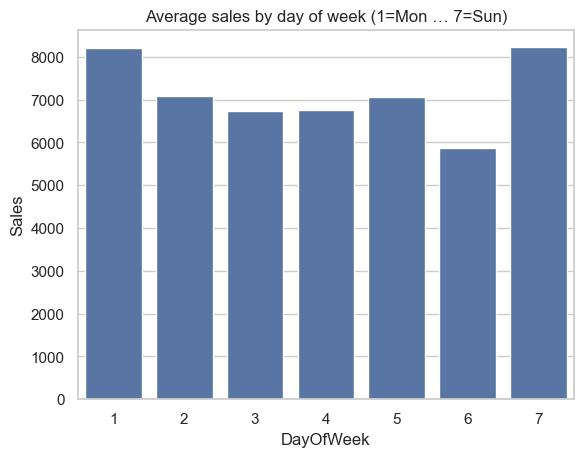

In [20]:
# Which weekdays drive sales? (→ staffing & delivery scheduling)
sns.barplot(data=open_df, x="DayOfWeek", y="Sales", estimator="mean", errorbar=None)
plt.title("Average sales by day of week (1=Mon … 7=Sun)"); plt.show()

In [27]:
# Of all Sunday rows, how many are open vs closed?
sun = df[df["DayOfWeek"] == 7]
print(sun["Open"].value_counts())
print("share of Sundays open:", round(sun["Open"].mean(), 4))

# And how many distinct stores ever open on a Sunday?
print("stores open on Sundays:", df[(df["DayOfWeek"] == 7) & (df["Open"] == 1)]["Store"].nunique())

Open
0    141137
1      3593
Name: count, dtype: int64
share of Sundays open: 0.0248
stores open on Sundays: 33


Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


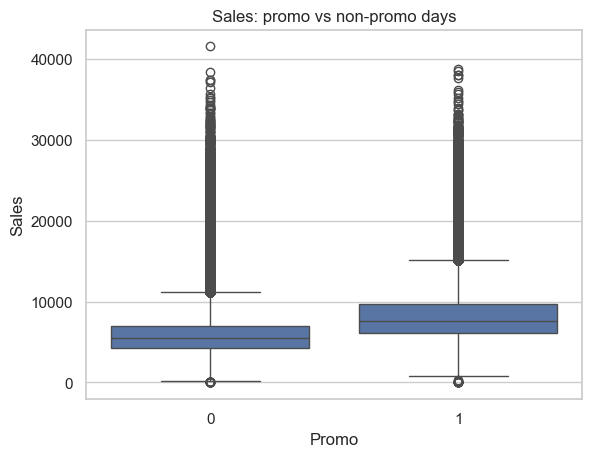

In [21]:
# Do promotions actually move the needle? - This is the most important driver — promotion is the biggest controllable lever
print(open_df.groupby("Promo")["Sales"].mean())
sns.boxplot(data=open_df, x="Promo", y="Sales")
plt.title("Sales: promo vs non-promo days"); plt.show()

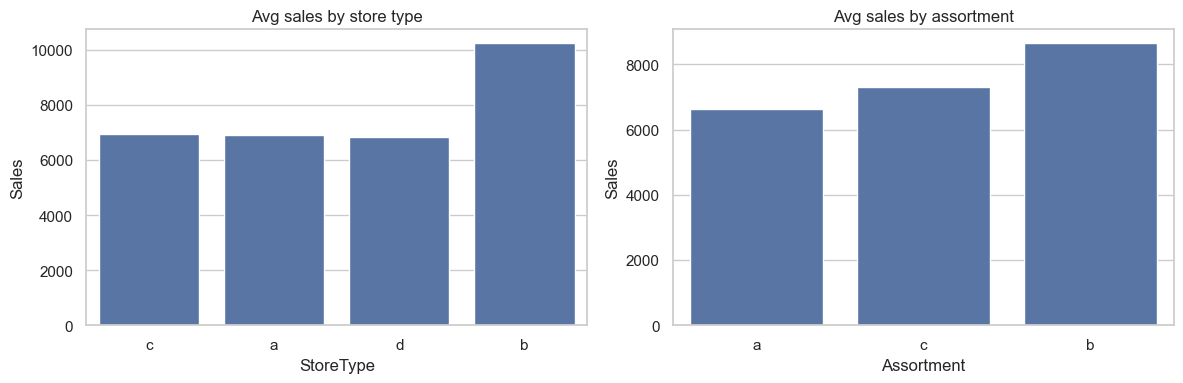

In [22]:
# Which store formats & assortments sell most?
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=open_df, x="StoreType", y="Sales", estimator="mean", errorbar=None, ax=ax[0])
ax[0].set_title("Avg sales by store type")
sns.barplot(data=open_df, x="Assortment", y="Sales", estimator="mean", errorbar=None, ax=ax[1])
ax[1].set_title("Avg sales by assortment")
plt.tight_layout(); plt.show()

In [23]:
# Does nearby competition hurt sales? 
open_df["comp_bin"] = pd.qcut(open_df["CompetitionDistance"], 5, duplicates="drop")
open_df.groupby("comp_bin", observed=True)["Sales"].mean()

comp_bin
(19.999, 510.0]      7596.008472
(510.0, 1590.0]      6836.670196
(1590.0, 3460.0]     6729.701250
(3460.0, 8780.0]     6793.139082
(8780.0, 75860.0]    6836.504177
Name: Sales, dtype: float64

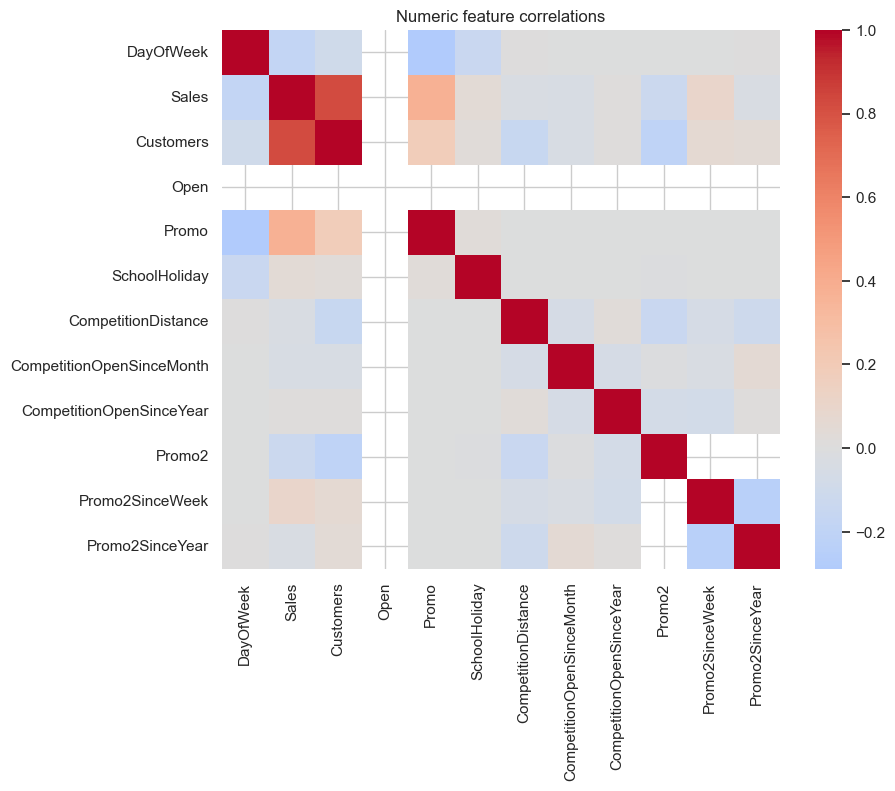

In [24]:
# A quick scan for strong / redundant numerical relationships
num = open_df.select_dtypes("number").drop(columns=["Store"], errors="ignore")
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(), cmap="coolwarm", center=0)
plt.title("Numeric feature correlations"); plt.show()

In [25]:
conn.close()

## 7. Business insights 

1. **Promotions**:  lift average daily sales from €5,929 → €8,228 (~+39%). Biggest controllable lever.
2. **December**: is the annual demand peak. Sales spike to ~8,600 (vs ~6,800 baseline) every December, then drop sharply in Jan → stock up ~6 weeks ahead.
3. **Store type B dominates**: (~€10,300/day vs ~€6,800 for a/c/d) — and assortment B is highest too. B is a small, high-value segment.
4. **Day of the week**: Monday (1) & Sunday (7) are highest (~8,200); Saturday (6) lowest (~5,850). Note: the few Sundays open are unusual high-traffic stores, which is why Sunday looks high.
5. **Competition distance**: weak effect — closest stores (<510m) sell slightly more (~7,600), but beyond that it's basically flat (~6,800). Counterintuitive; competitors cluster in high-footfall areas. Minor feature.
6. Sundays / closed days are ~all zero-sales → excluded from modelling as non-demand.
7. **Correlation heatmap**: Customers is by far the strongest correlate of Sales (expected), Promo second. Don't use Customers as a model feature — you won't know future customer counts at prediction time (leakage). StateHoliday ~all one value on open days → little signal, as noted.